# Wizualizacja danych z Pandas, Matplotlib i Seaborn

## 1. Import bibliotek

In [43]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Ustawienia dla czytelności wykresów
plt.rcParams.update({'font.size': 12})
sns.set_style("whitegrid")  # Styl seaborn

## 2. Przygotowanie danych

In [44]:
data = {
    "wojewodztwo": ["łódzkie", "łódzkie", "łódzkie", "łódzkie", "łódzkie",
                     "mazowieckie", "mazowieckie", "mazowieckie", "mazowieckie", "mazowieckie"],
    "rok": [2000, 2005, 2010, 2015, 2020,
            2000, 2005, 2010, 2015, 2020],
    "populacja_mln": [2.67, 2.59, 2.54, 2.49, 2.44,
                      5.07, 5.14, 5.24, 5.35, 5.42]
}
df_woj = pd.DataFrame(data)
df_woj.head(10)

,wojewodztwo,rok,populacja_mln
0,łódzkie,2000,2.67
1,łódzkie,2005,2.59
2,łódzkie,2010,2.54
3,łódzkie,2015,2.49
4,łódzkie,2020,2.44
5,mazowieckie,2000,5.07
6,mazowieckie,2005,5.14
7,mazowieckie,2010,5.24
8,mazowieckie,2015,5.35
9,mazowieckie,2020,5.42


In [45]:
df_woj.keys()

Index(['wojewodztwo', 'rok', 'populacja_mln'], dtype='object')

In [46]:
# Filtracja danych dla każdego województwa
mazowieckie = df_woj[df_woj["wojewodztwo"] == "mazowieckie"]
lodzkie = df_woj[df_woj["wojewodztwo"] == "łódzkie"]

In [47]:
lodzkie

,wojewodztwo,rok,populacja_mln
0,łódzkie,2000,2.67
1,łódzkie,2005,2.59
2,łódzkie,2010,2.54
3,łódzkie,2015,2.49
4,łódzkie,2020,2.44


## 3. WYKRES LINIOWY (Line Plot)

**Zastosowanie:** Przedstawianie zmian w czasie, trendów

(1999.0, 2021.0)

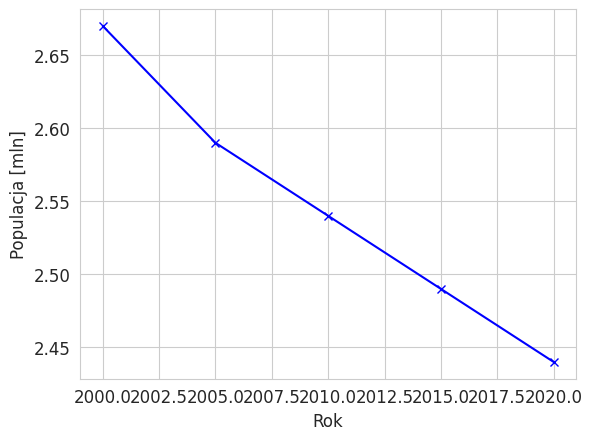

In [48]:
plt.plot(lodzkie["rok"], lodzkie["populacja_mln"], "bx-")
plt.xlabel("Rok")
plt.ylabel("Populacja [mln]")
plt.xlim([1999, 2021])

Text(0, 0.5, 'pop [mln]')

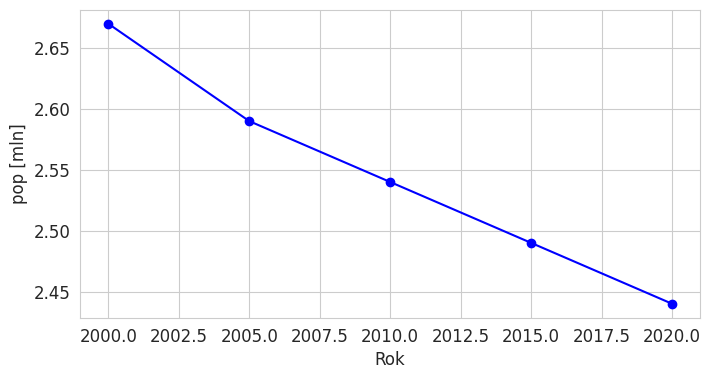

In [49]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lodzkie["rok"], lodzkie["populacja_mln"], 'bo-')
ax.set_xlabel("Rok")
ax.set_ylabel("pop [mln]")

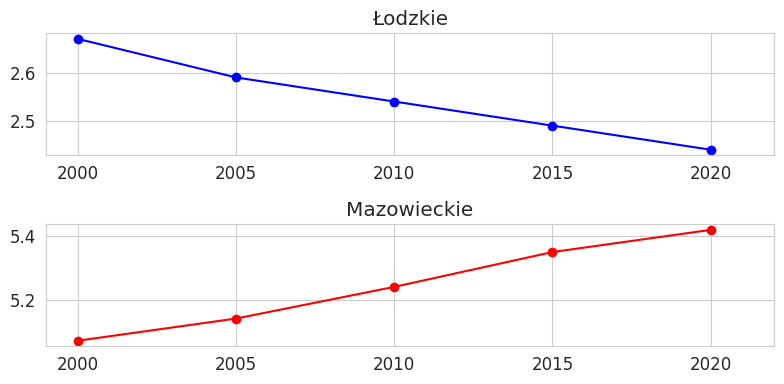

In [50]:
fig, ax = plt.subplots(2, 1, figsize=(8, 4))
ax[0].plot(lodzkie["rok"], lodzkie["populacja_mln"], 'bo-')
ax[0].set_title("Łodzkie")
ax[1].plot(mazowieckie["rok"], mazowieckie["populacja_mln"], 'ro-')
ax[0].set_xlim([1999, 2022])
ax[1].set_xlim([1999, 2022])
ax[1].set_title("Mazowieckie")
plt.tight_layout()

### Bezpośrednio `plot` na pandas DataFrame

<Axes: xlabel='rok'>

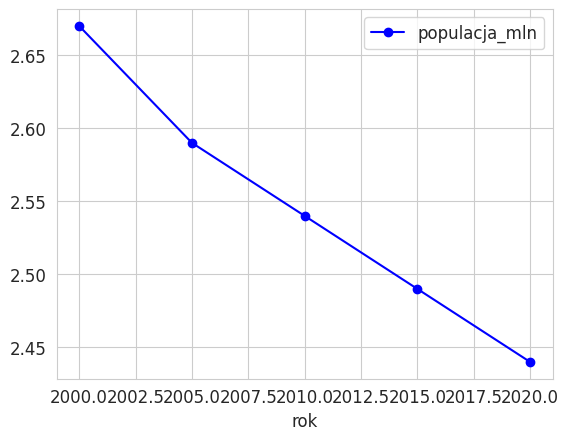

In [51]:
lodzkie.plot(x="rok", y="populacja_mln", marker="o", color="blue")

<Axes: xlabel='rok'>

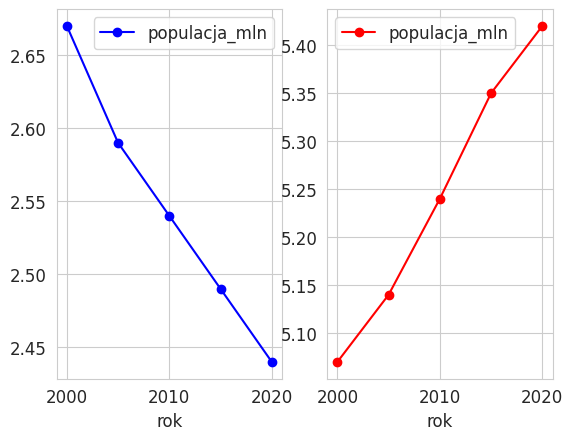

In [52]:
fig, ax = plt.subplots(1, 2)
lodzkie.plot(x="rok", y="populacja_mln", marker="o", color="blue", ax=ax[0])
mazowieckie.plot(x="rok", y="populacja_mln", marker="o", color="red", ax=ax[1])

## 4. WYKRES PUNKTOWY (Scatter Plot)

 **Zastosowanie:** Pokazywanie relacji między dwiema zmiennymi

In [53]:
# Generowanie dodatkowych danych dla scatter plot
np.random.seed(42)
scatter_data = pd.DataFrame({
    'temperatura': np.random.uniform(15, 35, 1500),
    'sprzedaz_lodow': np.random.uniform(50, 300, 1500)
})
# Dodajemy korelację
scatter_data['sprzedaz_lodow'] = scatter_data['sprzedaz_lodow'] + scatter_data['temperatura'] * 5

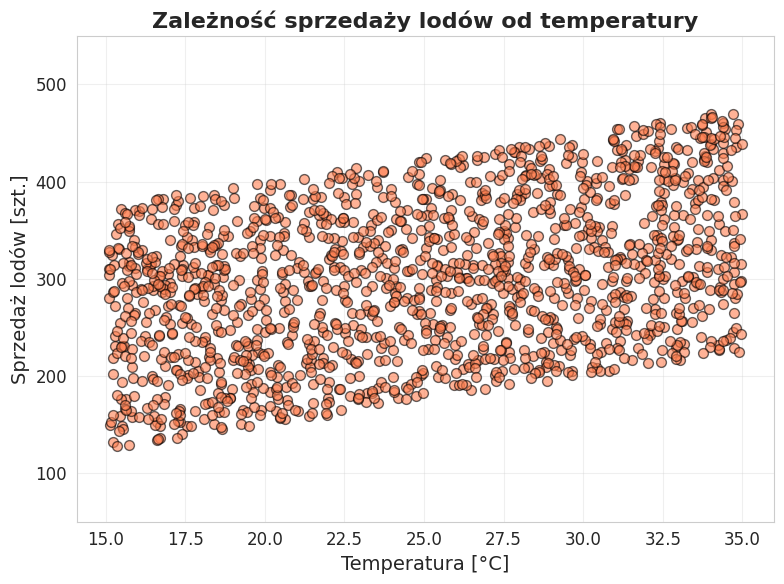

In [54]:
plt.figure(figsize=(8, 6))
plt.scatter(scatter_data['temperatura'], scatter_data['sprzedaz_lodow'],
            s=50, alpha=0.6, c='coral', edgecolors='black', linewidth=1)

plt.title('Zależność sprzedaży lodów od temperatury', fontsize=16, fontweight='bold')
plt.xlabel('Temperatura [°C]', fontsize=14)
plt.ylabel('Sprzedaż lodów [szt.]', fontsize=14)
plt.ylim([50, 550])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. WYKRES SŁUPKOWY (Bar Plot)

 **Zastosowanie:** Porównywanie wartości między kategoriami

In [55]:
# Dane dla wykresu słupkowego - populacja miast w dwóch różnych latach
miasta_data = pd.DataFrame({
    'miasto': ['Warszawa', 'Kraków', 'Łódź', 'Wrocław', 'Poznań'],
    'populacja_2022': [1795, 800, 670, 672, 545],
    'populacja_2010': [1700, 757, 730, 632, 550]
})

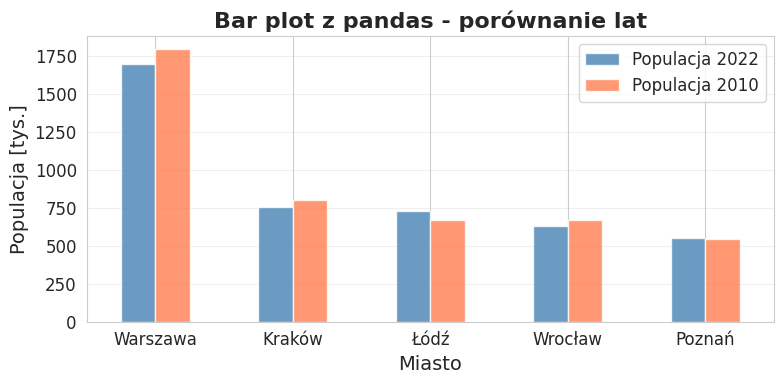

In [56]:
# Bar plot - Pandas

miasta_data.plot.bar(x='miasto', y=['populacja_2010', 'populacja_2022'],
                     figsize=(8, 4), color=['steelblue', 'coral'], alpha=0.8)
plt.title('Bar plot z pandas - porównanie lat', fontsize=16, fontweight='bold')
plt.xlabel('Miasto', fontsize=14)
plt.ylabel('Populacja [tys.]', fontsize=14)
plt.legend(['Populacja 2022', 'Populacja 2010'], fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Jak to zrobić z Seaborn?

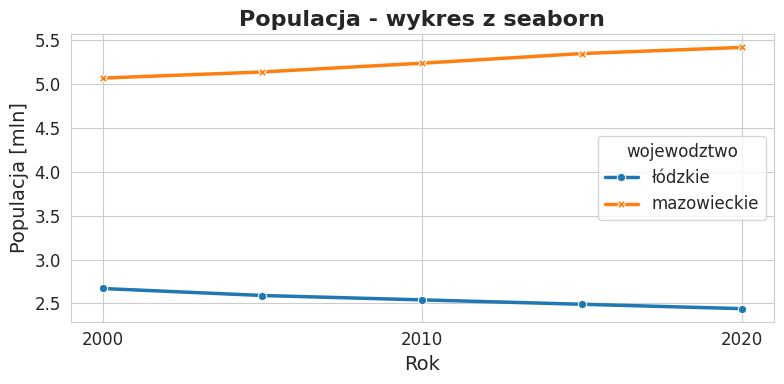

In [57]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=df_woj, x='rok', y='populacja_mln', hue='wojewodztwo',
             style='wojewodztwo', markers=True, dashes=False, linewidth=2.5)

plt.title('Populacja - wykres z seaborn', fontsize=16, fontweight='bold')
plt.xlabel('Rok', fontsize=14)
plt.ylabel('Populacja [mln]', fontsize=14)
plt.xticks([2000, 2010, 2020])
plt.tight_layout()
plt.show()

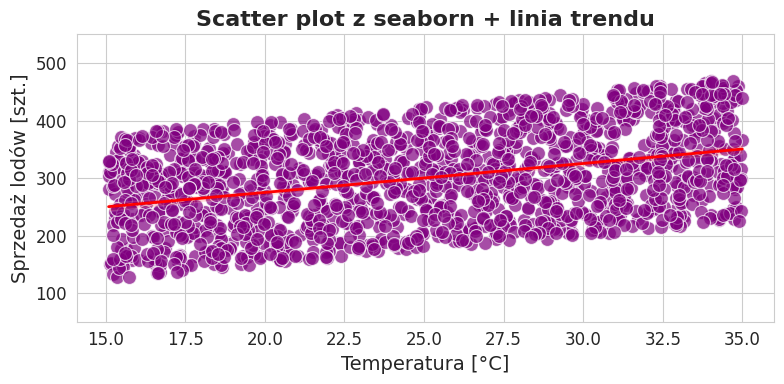

In [58]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=scatter_data, x='temperatura', y='sprzedaz_lodow',
                s=100, alpha=0.7, color='purple')
sns.regplot(data=scatter_data, x='temperatura', y='sprzedaz_lodow',
            scatter=False, color='red', line_kws={'linewidth': 2})

plt.title('Scatter plot z seaborn + linia trendu', fontsize=16, fontweight='bold')
plt.xlabel('Temperatura [°C]', fontsize=14)
plt.ylabel('Sprzedaż lodów [szt.]', fontsize=14)
plt.ylim([50, 550])
plt.tight_layout()
plt.show()

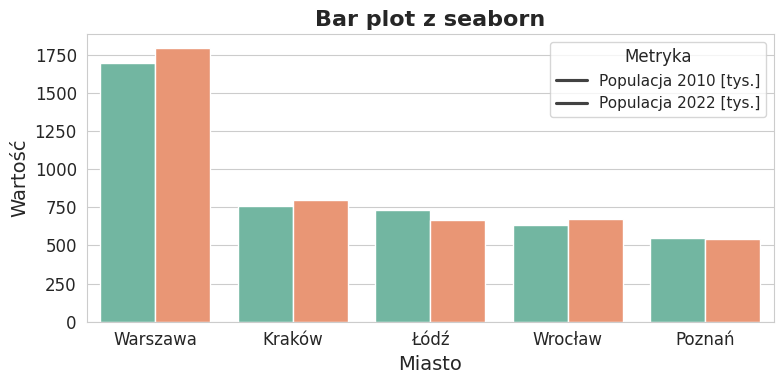

In [59]:
# Bar plot - Seaborn

# Przekształcenie danych do formatu długiego (long format)
miasta_long = pd.melt(miasta_data, id_vars=['miasto'],
                      value_vars=['populacja_2010', 'populacja_2022'],
                      var_name='Typ', value_name='Wartość')

plt.figure(figsize=(8, 4))
sns.barplot(data=miasta_long, x='miasto', y='Wartość', hue='Typ', palette='Set2')
plt.title('Bar plot z seaborn', fontsize=16, fontweight='bold')
plt.xlabel('Miasto', fontsize=14)
plt.ylabel('Wartość', fontsize=14)
plt.legend(title='Metryka', labels=['Populacja 2010 [tys.]', 'Populacja 2022 [tys.]'], fontsize=11)
plt.tight_layout()
plt.show()

# ZADANIA


## Zadanie 1: Podstawy DataFrame i wykres liniowy

**Dane:** Liczba mieszkańców Warszawy i Łodzi w wybranych latach:

| Rok  | Warszawa  | Łódź      |
|------|-----------|-----------|
| 2002 | 1672000   | 789318    |
| 2011 | 1707000   | 728892    |
| 2015 | 1740000   | 700982    |
| 2022 | 1795000   | 670642    |

**Polecenia:**
1. Utwórz słownik z powyższymi danymi
2. Stwórz DataFrame z tego słownika
5. **Stwórz wykres liniowy** pokazujący zmiany populacji obu miast w czasie
   - Użyj różnych kolorów i markerów dla każdego miasta
    - Dodaj tytuł, opisy osi i legendę
    - Wypróbuj wszystkie 3 metody (matplotlib, pandas, seaborn)

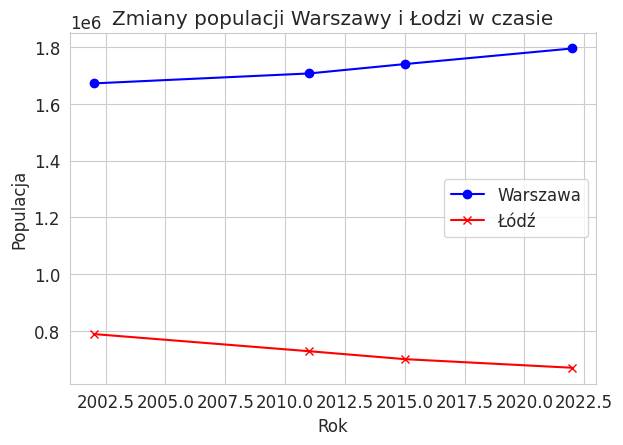

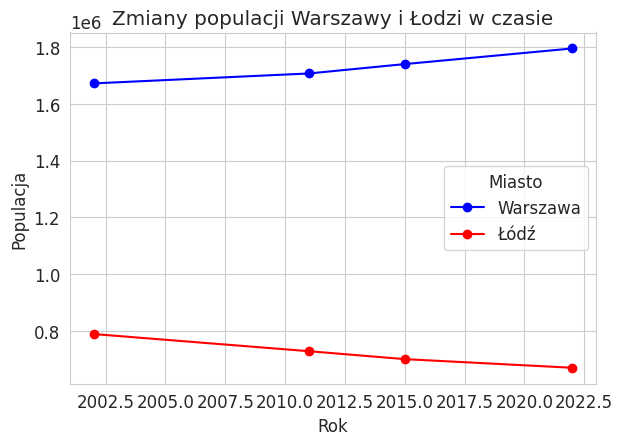

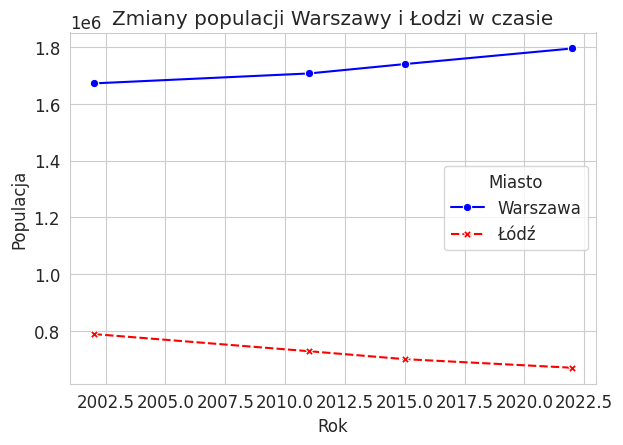

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    "Rok": [2002, 2011, 2015, 2022],
    "Warszawa": [1672000, 1707000, 1740000, 1795000],
    "Łódź": [789318, 728892, 700982, 670642]
}

df = pd.DataFrame(data)
df_melted = df.melt(id_vars="Rok", var_name="Miasto", value_name="Populacja")

# matplotlib
fig, ax = plt.subplots()
ax.plot(df["Rok"], df["Warszawa"], 'bo-', label="Warszawa")
ax.plot(df["Rok"], df["Łódź"], 'rx-', label="Łódź")
ax.set_title("Zmiany populacji Warszawy i Łodzi w czasie")
ax.set_xlabel("Rok")
ax.set_ylabel("Populacja")
ax.legend()
plt.tight_layout()
plt.show()

# pandas
df_melted.pivot(index="Rok", columns="Miasto", values="Populacja").plot(
    color={"Warszawa": "blue", "Łódź": "red"},
    marker='o',
    title="Zmiany populacji Warszawy i Łodzi w czasie"
)
plt.xlabel("Rok")
plt.ylabel("Populacja")
plt.legend(title="Miasto")
plt.tight_layout()
plt.show()

# seaborn
sns.lineplot(
    data=df_melted,
    x="Rok",
    y="Populacja",
    hue="Miasto",
    style="Miasto",
    markers={"Warszawa": "o", "Łódź": "X"},
    palette={"Warszawa": "blue", "Łódź": "red"}
)
plt.title("Zmiany populacji Warszawy i Łodzi w czasie")
plt.xlabel("Rok")
plt.ylabel("Populacja")
plt.tight_layout()
plt.show()

## Zadanie 2: Analiza danych o pojazdach w Łodzi

Dane pochodzą z portalu otwartych danych miasta Łodzi: https://otwarte.miasto.lodz.pl/transport_komunikacja/

### Do zrobienia:

1. **Wczytaj plik** `Pojazdy-ogolem-w-Lodzi.csv`

2. **Utwórz wykres punktowy** pokazujący zmianę liczby:
   - samochody osobowe
   - autobusy ogółem
   
   na przestrzeni lat. Dla każdego typu zrób osobny wykres.

3. **Utwórz wykres słupkowy** dla roku 2020 przedstawiający liczbę:
   - autobusów
   - samochodów osobowych
   - samochodów ciężarowych
   - motocykli

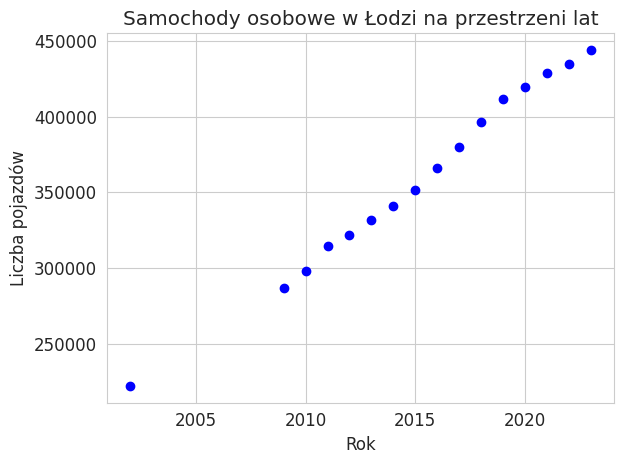

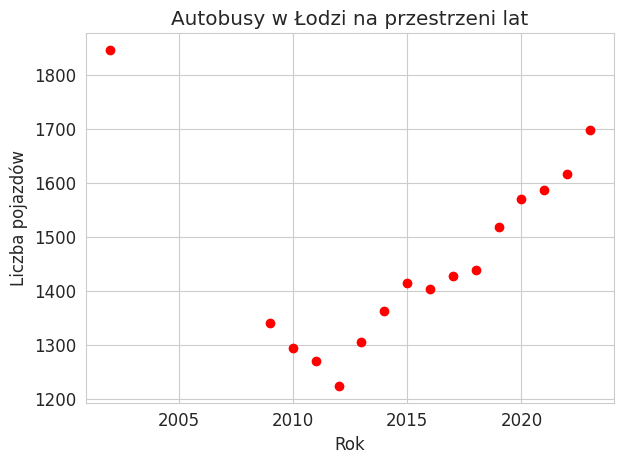

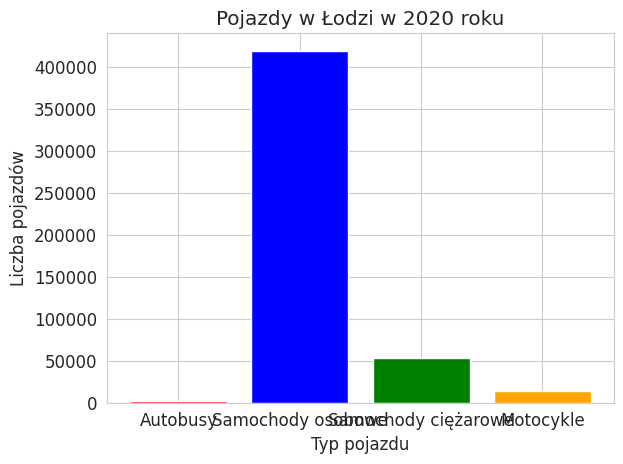

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Pojazdy-ogolem-w-Lodzi.csv', sep=';', encoding='utf-8-sig')

osobowe = df[df['zmienne'] == 'samochody osobowe']
autobusy = df[df['zmienne'] == 'autobusy ogółem']
ciezarowe = df[df['zmienne'] == 'samochody ciężarowe']
motocykle = df[df['zmienne'] == 'motocykle ogółem']

# wykres punktowy - samochody osobowe
plt.figure()
plt.scatter(osobowe['rok'], osobowe['wartość'], color='blue')
plt.title('Samochody osobowe w Łodzi na przestrzeni lat')
plt.xlabel('Rok')
plt.ylabel('Liczba pojazdów')
plt.tight_layout()
plt.show()

# wykres punktowy - autobusy
plt.figure()
plt.scatter(autobusy['rok'], autobusy['wartość'], color='red')
plt.title('Autobusy w Łodzi na przestrzeni lat')
plt.xlabel('Rok')
plt.ylabel('Liczba pojazdów')
plt.tight_layout()
plt.show()

# wykres słupkowy - rok 2020
kategorie = ['Autobusy', 'Samochody osobowe', 'Samochody ciężarowe', 'Motocykle']
wartosci_2020 = [
    autobusy[autobusy['rok'] == 2020]['wartość'].values[0],
    osobowe[osobowe['rok'] == 2020]['wartość'].values[0],
    ciezarowe[ciezarowe['rok'] == 2020]['wartość'].values[0],
    motocykle[motocykle['rok'] == 2020]['wartość'].values[0],
]

plt.figure()
plt.bar(kategorie, wartosci_2020, color=['red', 'blue', 'green', 'orange'])
plt.title('Pojazdy w Łodzi w 2020 roku')
plt.xlabel('Typ pojazdu')
plt.ylabel('Liczba pojazdów')
plt.tight_layout()
plt.show()